# Preprocessing (folder version)

Steps: 
- Parse PDB
- Compute relative positions
- Extract bond informations (bond length, angles, torsions)
- Assign partial charges
- Generate secondary structure labels
- Graph construction


## Libraries

In [1]:
import os
from Bio import PDB
import numpy as np
from tqdm import tqdm
import networkx as nx
from Bio.PDB.DSSP import DSSP
import graphein.protein as gp
from graphein.protein.config import ProteinGraphConfig
from graphein.protein.features.nodes import amino_acid_one_hot

## Function

In [2]:
def parse_pdb(pdb_filename):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("Protein", pdb_filename)
    
    atoms = []
    residues = []
    
    # Keep track of processed residues by chain
    all_residues_by_chain = {}
    
    for model in structure:
        for chain in model:
            chain_id = chain.get_id()
            chain_residues = []
            
            for residue in chain:
                # Get residue details
                residue_id = residue.get_id()[1]  # The sequence number
                residue_name = residue.get_resname()
                
                # Add residue to this chain's list
                chain_residues.append((residue_id, residue_name))
                
                # Process all atoms in this residue
                for atom in residue:
                    atom_name = atom.get_name()
                    element = atom.element
                    position = atom.get_coord()
                    # Include chain ID in atom information for clarity
                    atoms.append((chain_id, residue_id, residue_name, atom_name, element, position))
            
            # Store all residues for this chain
            all_residues_by_chain[chain_id] = chain_residues
    
    # Option 1: Return separate residue lists for each chain --> better for our pipeline
    return atoms, all_residues_by_chain

In [3]:
def process_pdb_folder(folder_path, output_path=None):
    """
    Process all PDB files in a folder and prepare data for PINN GNN.
    
    Parameters:
    folder_path -- Path to the folder containing PDB files
    output_path -- Optional path to save processed data
    
    Returns:
    Dictionary containing processed data for all PDB files
    """
    if output_path is None:
        output_path = os.path.join(folder_path, "processed_data")
    
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Get all PDB files in the folder
    pdb_files = [f for f in os.listdir(folder_path) if f.endswith('.pdb')]
    
    # Dictionary to store all processed data
    all_data = {}
    
    # Process each PDB file
    for pdb_file in tqdm(pdb_files, desc="Processing PDB files"):
        pdb_path = os.path.join(folder_path, pdb_file)
        pdb_id = os.path.splitext(pdb_file)[0]  # PDB ID without extension
        
        try:
            # Parse PDB file
            atoms, residues_by_chain = parse_pdb(pdb_path)
            
            # Process data for this PDB
            pdb_data = process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain)
            
            # Store in the main dictionary
            all_data[pdb_id] = pdb_data
            
            # Save processed data
            if output_path:
                # Save the NetworkX graph
                graph_path = os.path.join(output_path, f"{pdb_id}_graph.pkl")
                try:
                    # Try newer NetworkX API first
                    import pickle
                    with open(graph_path, 'wb') as f:
                        pickle.dump(pdb_data['nx_graph'], f)
                    print(f"Saved graph to {graph_path}")
                except Exception as e:
                    print(f"Error saving graph for {pdb_id}: {str(e)}")
                
                # Save other data as numpy file
                # Remove graph from data to save separately (graphs can be large)
                data_to_save = {k: v for k, v in pdb_data.items() if k != 'nx_graph'}
                data_path = os.path.join(output_path, f"{pdb_id}_data.npy")
                try:
                    np.save(data_path, data_to_save)
                    print(f"Saved data to {data_path}")
                except Exception as e:
                    print(f"Error saving data for {pdb_id}: {str(e)}")
                
        except Exception as e:
            print(f"Error processing {pdb_file}: {str(e)}")
    
    # Save summary of all processed data
    summary = {}
    for pdb_id, pdb_data in all_data.items():
        summary[pdb_id] = {
            'num_atoms': len(pdb_data['atoms']),
            'num_chains': len(pdb_data['residues_by_chain']),
            'chains': list(pdb_data['residues_by_chain'].keys()),
            'num_nodes': pdb_data['nx_graph'].number_of_nodes(),
            'num_edges': pdb_data['nx_graph'].number_of_edges()
        }
    
    summary_path = os.path.join(output_path, "processing_summary.json")
    try:
        import json
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"Saved processing summary to {summary_path}")
    except Exception as e:
        print(f"Error saving summary: {str(e)}")
    
    return all_data




# def process_pdb_folder(folder_path, output_path=None):
#     """
#     Process all PDB files in a folder and prepare data for PINN GNN.
    
#     Parameters:
#     folder_path -- Path to the folder containing PDB files
#     output_path -- Optional path to save processed data
    
#     Returns:
#     Dictionary containing processed data for all PDB files
#     """
#     if output_path is None:
#         output_path = os.path.join(folder_path, "processed_data")
    
#     # Create output directory if it doesn't exist
#     os.makedirs(output_path, exist_ok=True)
    
#     # Get all PDB files in the folder
#     pdb_files = [f for f in os.listdir(folder_path) if f.endswith('.pdb')]
    
#     # Dictionary to store all processed data
#     all_data = {}
    
    # # Process each PDB file
    # for pdb_file in tqdm(pdb_files, desc="Processing PDB files"):
    #     pdb_path = os.path.join(folder_path, pdb_file)
    #     pdb_id = os.path.splitext(pdb_file)[0]  # PDB ID without extension
        
    #     try:
    #         # Parse PDB file
    #         atoms, residues_by_chain = parse_pdb(pdb_path)
            
    #         # Process data for this PDB
    #         pdb_data = process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain)
            
    #         # Store in the main dictionary
    #         all_data[pdb_id] = pdb_data
            
    #         # Optionally save individual processed data
    #         if output_path:
    #             nx.write_gpickle(pdb_data['nx_graph'], os.path.join(output_path, f"{pdb_id}_graph.gpickle"))
    #             np.save(os.path.join(output_path, f"{pdb_id}_data.npy"), 
    #                     {k: v for k, v in pdb_data.items() if k != 'nx_graph'})
                
    #     except Exception as e:
    #         print(f"Error processing {pdb_file}: {str(e)}")
    
    # return all_data

def process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain):
    """
    Process a single PDB file data for the PINN GNN model.
    
    Parameters:
    pdb_id -- Identifier for the PDB
    pdb_path -- Path to the PDB file
    atoms -- List of atom information from parse_pdb
    residues_by_chain -- Dictionary of residues by chain from parse_pdb
    
    Returns:
    Dictionary containing all processed data for this PDB
    """
    # Dictionary to store processed data
    pdb_data = {
        'pdb_id': pdb_id,
        'atoms': atoms,
        'residues_by_chain': residues_by_chain,
        'relative_positions': {},
        'edge_indices': {},
        'bond_lengths': {},
        'angles': {},
        'torsions': {},
        'secondary_structure': {},
        'backbone_atoms': {},
        'charges': {},
        'hydrophobic_residues': {},
        'nx_graph': None
    }
    
    # Calculate secondary structure using DSSP
    ss_data = calculate_secondary_structure(pdb_path)
    
    # Create NetworkX graph using Graphein
    nx_graph = create_protein_graph(pdb_path)
    pdb_data['nx_graph'] = nx_graph
    
    # Process each chain
    for chain_id, chain_residues in residues_by_chain.items():
        # Get atoms for this chain
        chain_atoms = [atom for atom in atoms if atom[0] == chain_id]
        
        # Extract positions
        positions = np.array([atom[5] for atom in chain_atoms])
        
        # Compute relative positions
        rel_pos = compute_relative_positions_chain(positions)
        
        # Create edge index for graph construction
        edge_index = create_edge_index(chain_atoms)
        
        # Get backbone atoms
        backbone_atoms = extract_backbone_atoms(chain_atoms)
        
        # Get secondary structure for this chain
        chain_ss = {res_id: ss_data.get((chain_id, res_id), '?') 
                   for res_id, _ in chain_residues}
        
        # Calculate physical properties
        bond_lengths = calculate_bond_lengths(chain_atoms, edge_index)
        angles = calculate_angles(chain_atoms, edge_index)
        torsions = calculate_torsions(chain_atoms, edge_index)
        charges = assign_charges(chain_atoms)
        hydrophobic = identify_hydrophobic_residues(chain_residues)
        
        # Store in PDB data dictionary
        pdb_data['relative_positions'][chain_id] = rel_pos
        pdb_data['edge_indices'][chain_id] = edge_index
        pdb_data['bond_lengths'][chain_id] = bond_lengths
        pdb_data['angles'][chain_id] = angles
        pdb_data['torsions'][chain_id] = torsions
        pdb_data['secondary_structure'][chain_id] = chain_ss
        pdb_data['backbone_atoms'][chain_id] = backbone_atoms
        pdb_data['charges'][chain_id] = charges
        pdb_data['hydrophobic_residues'][chain_id] = hydrophobic
    
    return pdb_data


def calculate_secondary_structure(pdb_path):
    """
    Calculate secondary structure using DSSP.
    
    Parameters:
    pdb_path -- Path to the PDB file
    
    Returns:
    Dictionary mapping (chain_id, residue_id) to secondary structure
    """
    try:
        parser = PDB.PDBParser(QUIET=True)
        structure = parser.get_structure("protein", pdb_path)
        model = structure[0]
        
        try:
            # Try direct DSSP call
            dssp = DSSP(model, pdb_path)
        except Exception as e1:
            try:
                # Fallback: Try with DSSP executable if installed
                from Bio.PDB.DSSP import dssp_dict_from_pdb_file
                dssp_dict, dssp_keys = dssp_dict_from_pdb_file(pdb_path)
                
                # Convert to format similar to DSSP object
                dssp = {}
                for key in dssp_keys:
                    dssp[key] = dssp_dict[key]
            except Exception as e2:
                print(f"DSSP calculation failed: {str(e1)} | {str(e2)}")
                # If all methods fail, use a simple fallback
                return {}
        
        ss_data = {}
        
        for key in dssp.keys():
            if isinstance(key, tuple):
                # Newer DSSP version
                chain_id = key[0]
                res_id = key[1][1]  # Residue number
                if isinstance(dssp[key], dict):
                    ss = dssp[key].get('secstruct', '?')
                else:
                    # Older DSSP version
                    ss = dssp[key][2]  # Secondary structure
            else:
                # Alternative key format
                chain_id, res_id = key[0], key[1]
                ss = dssp[key][2]
                
            ss_data[(chain_id, res_id)] = ss
        
        return ss_data
    except Exception as e:
        print(f"Secondary structure calculation failed: {str(e)}")
        return {}

def create_protein_graph(pdb_path):
    """
    Create a protein graph using Graphein or fallback to custom implementation.
    
    Parameters:
    pdb_path -- Path to the PDB file
    
    Returns:
    NetworkX graph
    """
    try:
        # Try the current Graphein API
        import graphein.protein as gp
        
        # Check the actual function signature
        import inspect
        sig = inspect.signature(gp.construct_graph)
        
        # Check if 'pdb_path' is a parameter
        if 'pdb_path' in sig.parameters:
            graph = gp.construct_graph(pdb_path=pdb_path)
        elif 'path' in sig.parameters:
            # Try with 'path' instead
            graph = gp.construct_graph(path=pdb_path)
        else:
            # Check if the function expects the first argument to be the path
            params = list(sig.parameters.keys())
            if len(params) > 0:
                # Try with positional argument
                graph = gp.construct_graph(pdb_path)
            else:
                raise ValueError("Cannot determine correct parameters for construct_graph")
                
        return graph
        
    except Exception as e:
        print(f"Graphein error: {str(e)}")
        print("Falling back to custom graph implementation...")
        
        # Create a simple graph using NetworkX and BioPython
        parser = PDB.PDBParser(QUIET=True)
        structure = parser.get_structure("protein", pdb_path)
        
        # Create basic graph
        graph = nx.Graph()
        
        # Add nodes for each residue
        for model in structure:
            for chain in model:
                chain_id = chain.get_id()
                for residue in chain:
                    # Skip non-standard residues
                    if residue.get_id()[0] != " ":
                        continue
                        
                    res_id = residue.get_id()[1]
                    res_name = residue.get_resname()
                    
                    # Add node
                    node_id = f"{chain_id}_{res_id}"
                    graph.add_node(
                        node_id,
                        chain_id=chain_id,
                        residue_number=res_id,
                        residue_name=res_name
                    )
                    
                    # Add atom data
                    ca_coord = None
                    for atom in residue:
                        atom_name = atom.get_name()
                        coord = atom.get_coord()
                        
                        if atom_name == 'CA':
                            ca_coord = coord
                            
                        # Store coordinates of backbone atoms
                        if atom_name in ['CA', 'N', 'C', 'O']:
                            graph.nodes[node_id][atom_name] = coord
                    
                    # Store CA coordinates for distance calculations
                    if ca_coord is not None:
                        graph.nodes[node_id]['coords'] = ca_coord
        
        # Add edges between consecutive residues and close residues
        # First, sort nodes by chain and residue number
        sorted_nodes = sorted(graph.nodes(), key=lambda x: (x.split('_')[0], int(x.split('_')[1])))
        
        # Add backbone connections
        for i in range(len(sorted_nodes) - 1):
            node1 = sorted_nodes[i]
            chain1, res1 = node1.split('_')
            
            for j in range(i + 1, min(i + 20, len(sorted_nodes))):  # Check only nearby residues
                node2 = sorted_nodes[j]
                chain2, res2 = node2.split('_')
                
                # Add edge if same chain and sequential
                if chain1 == chain2 and abs(int(res1) - int(res2)) == 1:
                    graph.add_edge(node1, node2, kind='peptide_bond')
                
                # Add edge if CA atoms are within 7 Angstroms
                if 'coords' in graph.nodes[node1] and 'coords' in graph.nodes[node2]:
                    ca1 = graph.nodes[node1]['coords']
                    ca2 = graph.nodes[node2]['coords']
                    distance = np.linalg.norm(ca1 - ca2)
                    
                    if distance < 7.0:  # 7 Angstrom cutoff
                        graph.add_edge(node1, node2, kind='contact', weight=distance)
        
        return graph

def extract_backbone_atoms(chain_atoms):
    """
    Extract backbone atoms (N, CA, C, O) from a chain.
    
    Parameters:
    chain_atoms -- List of atoms in a chain
    
    Returns:
    Dictionary mapping residue IDs to backbone atom positions
    """
    backbone = {}
    
    for atom in chain_atoms:
        chain_id, res_id, res_name, atom_name, element, position = atom
        
        if atom_name in ['N', 'CA', 'C', 'O']:
            if res_id not in backbone:
                backbone[res_id] = {}
            backbone[res_id][atom_name] = position
    
    return backbone

def compute_relative_positions_chain(positions):
    """Compute relative positions between atoms in a chain."""
    n_atoms = positions.shape[0]
    rel_pos = np.zeros((n_atoms, n_atoms, 3))
    
    for i in range(n_atoms):
        for j in range(n_atoms):
            rel_pos[i, j] = positions[j] - positions[i]
    
    return rel_pos

def create_edge_index(chain_atoms):
    """Create edge index for graph construction."""
    n_atoms = len(chain_atoms)
    edges = []
    
    # Example: Connect atoms within the same residue and consecutive residues
    for i in range(n_atoms):
        res_i = chain_atoms[i][1]  # Residue ID
        for j in range(i+1, n_atoms):
            res_j = chain_atoms[j][1]  # Residue ID
            if res_i == res_j or abs(res_i - res_j) == 1:
                edges.append([i, j])
                edges.append([j, i])  # For undirected graph
    
    return np.array(edges).T if edges else np.zeros((2, 0), dtype=int)

def calculate_bond_lengths(chain_atoms, edge_index):
    """Placeholder for bond length calculation"""
    # Here you would implement actual bond length calculation
    return {}

def calculate_angles(chain_atoms, edge_index):
    """Placeholder for angle calculation"""
    # Here you would implement actual angle calculation
    return {}

def calculate_torsions(chain_atoms, edge_index):
    """Placeholder for torsion calculation"""
    # Here you would implement actual torsion calculation
    return {}

def assign_charges(chain_atoms):
    """
    Assign partial charges to atoms based on residue type and atom name.
    
    This is a simplified version - you may want to use a more accurate charge model.
    """
    charges = {}
    
    # Simplified charge assignment based on atom types
    charge_map = {
        'N': -0.5,   # Backbone nitrogen
        'C': 0.5,    # Backbone carbon
        'O': -0.5,   # Carbonyl oxygen
        'S': 0.0,    # Sulfur
        'P': 0.5     # Phosphorus
    }
    
    for i, atom in enumerate(chain_atoms):
        chain_id, res_id, res_name, atom_name, element, position = atom
        charges[i] = charge_map.get(element, 0.0)
    
    return charges

def identify_hydrophobic_residues(chain_residues):
    """
    Identify hydrophobic residues in a chain.
    
    Parameters:
    chain_residues -- List of residues in a chain
    
    Returns:
    Set of residue IDs that are hydrophobic
    """
    hydrophobic_aas = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'TYR'}
    hydrophobic_res_ids = set()
    
    for res_id, res_name in chain_residues:
        if res_name in hydrophobic_aas:
            hydrophobic_res_ids.add(res_id)
    
    return hydrophobic_res_ids

### Test process one PDB

In [4]:
def test_process_single_pdb(pdb_path):
    """
    Test processing a single PDB file and output detailed diagnostic information.
    
    Parameters:
    pdb_path -- Path to the PDB file
    
    Returns:
    The processed data or None if processing failed
    """
    print(f"\nTesting PDB processing for: {pdb_path}")
    pdb_id = os.path.splitext(os.path.basename(pdb_path))[0]
    
    try:
        print("1. Parsing PDB file...")
        atoms, residues_by_chain = parse_pdb(pdb_path)
        print(f"   Found {len(atoms)} atoms across {len(residues_by_chain)} chains")
        
        for chain_id, residues in residues_by_chain.items():
            print(f"   Chain {chain_id}: {len(residues)} residues")
        
        print("\n2. Calculating secondary structure...")
        ss_data = calculate_secondary_structure(pdb_path)
        print(f"   Found secondary structure for {len(ss_data)} residues")
        
        print("\n3. Creating protein graph...")
        nx_graph = create_protein_graph(pdb_path)
        print(f"   Created graph with {nx_graph.number_of_nodes()} nodes and {nx_graph.number_of_edges()} edges")
        
        print("\n4. Processing full PDB data...")
        pdb_data = process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain)
        print("   Processing complete")
        
        return pdb_data
        
    except Exception as e:
        print(f"Error processing {pdb_path}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

In [5]:
def process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain):
    """
    Process a single PDB file data for the PINN GNN model.
    
    Parameters:
    pdb_id -- Identifier for the PDB
    pdb_path -- Path to the PDB file
    atoms -- List of atom information from parse_pdb
    residues_by_chain -- Dictionary of residues by chain from parse_pdb
    
    Returns:
    Dictionary containing all processed data for this PDB
    """
    # Dictionary to store processed data
    pdb_data = {
        'pdb_id': pdb_id,
        'atoms': atoms,
        'residues_by_chain': residues_by_chain,
        'relative_positions': {},
        'edge_indices': {},
        'bond_lengths': {},
        'angles': {},
        'torsions': {},
        'secondary_structure': {},
        'backbone_atoms': {},
        'charges': {},
        'hydrophobic_residues': {},
        'nx_graph': None
    }
    
    # Calculate secondary structure using DSSP
    ss_data = calculate_secondary_structure(pdb_path)
    
    # Create NetworkX graph using Graphein or fallback
    nx_graph = create_protein_graph(pdb_path)
    pdb_data['nx_graph'] = nx_graph
    
    # Process each chain
    for chain_id, chain_residues in residues_by_chain.items():
        # Get atoms for this chain
        chain_atoms = [atom for atom in atoms if atom[0] == chain_id]
        
        # Skip empty chains
        if not chain_atoms:
            continue
            
        # Extract positions
        positions = np.array([atom[5] for atom in chain_atoms])
        
        # Compute relative positions
        rel_pos = compute_relative_positions_chain(positions)
        
        # Create edge index for graph construction
        edge_index = create_edge_index(chain_atoms)
        
        # Get backbone atoms
        backbone_atoms = extract_backbone_atoms(chain_atoms)
        
        # Get secondary structure for this chain
        chain_ss = {res_id: ss_data.get((chain_id, res_id), '?') 
                   for res_id, _ in chain_residues}
        
        # Simple placeholders for physical properties - implement these as needed
        bond_lengths = {}  # Placeholder
        angles = {}  # Placeholder
        torsions = {}  # Placeholder
        charges = assign_charges(chain_atoms)
        hydrophobic = identify_hydrophobic_residues(chain_residues)
        
        # Store in PDB data dictionary
        pdb_data['relative_positions'][chain_id] = rel_pos
        pdb_data['edge_indices'][chain_id] = edge_index
        pdb_data['bond_lengths'][chain_id] = bond_lengths
        pdb_data['angles'][chain_id] = angles
        pdb_data['torsions'][chain_id] = torsions
        pdb_data['secondary_structure'][chain_id] = chain_ss
        pdb_data['backbone_atoms'][chain_id] = backbone_atoms
        pdb_data['charges'][chain_id] = charges
        pdb_data['hydrophobic_residues'][chain_id] = hydrophobic
    
    return pdb_data

### Inspect PDB

In [6]:
def inspect_protein_graph(graph, pdb_id=None):
    """
    Inspect a protein graph to verify its structure and properties.
    
    Parameters:
    graph -- NetworkX graph object to inspect
    pdb_id -- Optional PDB ID for display purposes
    
    Returns:
    None (prints information to console)
    """
    if pdb_id:
        print(f"\n==== INSPECTING PROTEIN GRAPH: {pdb_id} ====\n")
    else:
        print("\n==== INSPECTING PROTEIN GRAPH ====\n")
    
    # Basic graph information
    print(f"Graph type: {type(graph)}")
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    
    # Check node information
    if graph.number_of_nodes() > 0:
        print("\n-- NODE INFORMATION --")
        # Get a sample node
        sample_node = next(iter(graph.nodes()))
        print(f"\nSample node ID: {sample_node}")
        print("Node attributes:")
        for key, value in graph.nodes[sample_node].items():
            if isinstance(value, np.ndarray) and value.size > 10:
                print(f"  {key}: <ndarray shape={value.shape}, dtype={value.dtype}>")
            else:
                print(f"  {key}: {value}")
        
        # Count of nodes by chain
        chains = {}
        for node in graph.nodes():
            chain = graph.nodes[node].get('chain_id', 'Unknown')
            chains[chain] = chains.get(chain, 0) + 1
        print("\nNodes by chain:")
        for chain, count in chains.items():
            print(f"  Chain {chain}: {count} nodes")
    
    # Check edge information
    if graph.number_of_edges() > 0:
        print("\n-- EDGE INFORMATION --")
        # Get a sample edge
        sample_edge = next(iter(graph.edges()))
        print(f"\nSample edge: {sample_edge}")
        print("Edge attributes:")
        for key, value in graph.edges[sample_edge].items():
            print(f"  {key}: {value}")
        
        # Count edge types
        edge_types = {}
        for u, v, data in graph.edges(data=True):
            # Handle different possible formats of 'kind' attribute
            kind = data.get('kind', 'Unknown')
            
            if isinstance(kind, set):
                # If kind is a set, convert to tuple for hashing
                for k in kind:
                    edge_types[k] = edge_types.get(k, 0) + 1
            elif isinstance(kind, list):
                # If kind is a list, count each type
                for k in kind:
                    edge_types[k] = edge_types.get(k, 0) + 1
            else:
                # Otherwise use as-is
                edge_types[kind] = edge_types.get(kind, 0) + 1
        
        print("\nEdge types:")
        for edge_type, count in edge_types.items():
            print(f"  {edge_type}: {count} edges")
    
    # Check for secondary structure
    has_ss = False
    for node in graph.nodes():
        if 'ss' in graph.nodes[node]:
            has_ss = True
            break
    print(f"\nSecondary structure information: {'Present' if has_ss else 'Missing'}")
    
    # Check for backbone atoms
    has_backbone = False
    for node in graph.nodes():
        if any(key in graph.nodes[node] for key in ['CA', 'N', 'C', 'O']):
            has_backbone = True
            break
    print(f"Backbone atom information: {'Present' if has_backbone else 'Missing'}")
    
    print("\n==== INSPECTION COMPLETE ====\n")

### Visualization 

In [7]:
def visualize_protein_graph(graph, pdb_id=None, output_path=None):
    """
    Visualize the protein graph using matplotlib.
    
    Parameters:
    graph -- NetworkX graph
    pdb_id -- Optional PDB ID for title
    output_path -- Optional path to save the visualization
    
    Returns:
    None (displays or saves the plot)
    """
    import matplotlib.pyplot as plt
    
    if graph.number_of_nodes() == 0:
        print("Cannot visualize empty graph!")
        return
    
    # Set up figure
    plt.figure(figsize=(12, 10))
    
    # Collect node positions and colors
    pos = {}
    colors = []
    sizes = []
    
    # Determine if 'coords' attribute exists or needs to be derived
    has_coords = False
    for node in list(graph.nodes())[:5]:  # Check first few nodes
        if 'coords' in graph.nodes[node]:
            has_coords = True
            break
    
    # For each node, get position and color
    for node in graph.nodes():
        # Get chain_id
        chain_id = graph.nodes[node].get('chain_id', 'Unknown')
        
        # Get position
        if has_coords and 'coords' in graph.nodes[node]:
            coords = graph.nodes[node]['coords']
            if isinstance(coords, np.ndarray) and coords.size >= 2:
                pos[node] = (coords[0], coords[1])
            elif isinstance(coords, list) and len(coords) >= 2:
                pos[node] = (coords[0], coords[1])
        elif 'CA' in graph.nodes[node]:
            # Use CA atom position if coords not available
            ca_pos = graph.nodes[node]['CA']
            if isinstance(ca_pos, np.ndarray) and ca_pos.size >= 2:
                pos[node] = (ca_pos[0], ca_pos[1])
            elif isinstance(ca_pos, list) and len(ca_pos) >= 2:
                pos[node] = (ca_pos[0], ca_pos[1])
        
        # Add color based on chain
        if chain_id == 'L':
            colors.append('blue')
        elif chain_id == 'H':
            colors.append('red')
        else:
            colors.append('gray')
        
        # Node size
        sizes.append(30)  # Default size
    
    # If we couldn't get positions for nodes, use spring layout
    if len(pos) < graph.number_of_nodes() * 0.5:  # If less than half the nodes have positions
        print("Using spring layout as fallback")
        pos = nx.spring_layout(graph, seed=42)
    
    # Draw the graph
    nx.draw(
        graph,
        pos=pos,
        node_color=colors,
        node_size=sizes,
        with_labels=False,
        edge_color='gray',
        width=0.5,
        alpha=0.7
    )
    
    # Add title
    title = f"Protein Graph: {pdb_id}" if pdb_id else "Protein Graph"
    plt.title(title)
    plt.axis('off')
    
    # Add legend
    import matplotlib.lines as mlines
    legend_handles = []
    
    if 'blue' in colors:
        legend_handles.append(mlines.Line2D([], [], color='blue', marker='o', 
                                          linestyle='None', markersize=10, label='Chain L'))
    if 'red' in colors:
        legend_handles.append(mlines.Line2D([], [], color='red', marker='o', 
                                          linestyle='None', markersize=10, label='Chain H'))
    if 'gray' in colors:
        legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', 
                                          linestyle='None', markersize=10, label='Other'))
    
    plt.legend(handles=legend_handles)
    
    # Save or show
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()

### Try

Output()


Testing PDB processing for: fabs/1GHF.pdb
1. Parsing PDB file...
   Found 3273 atoms across 2 chains
   Chain L: 211 residues
   Chain H: 212 residues

2. Calculating secondary structure...
   Found secondary structure for 423 residues

3. Creating protein graph...


   Created graph with 423 nodes and 420 edges

4. Processing full PDB data...


Output()

   Processing complete

==== INSPECTING PROTEIN GRAPH: 1GHF.pdb ====

Graph type: <class 'networkx.classes.graph.Graph'>
Number of nodes: 423
Number of edges: 420

-- NODE INFORMATION --

Sample node ID: H:VAL:1
Node attributes:
  chain_id: H
  residue_name: VAL
  residue_number: 1
  atom_type: CA
  element_symbol: C
  coords: [78.176 45.718 -9.696]
  b_factor: 11.399999618530273
  meiler: dim_1    3.67
dim_2    0.14
dim_3    3.00
dim_4    1.22
dim_5    6.02
dim_6    0.27
dim_7    0.49
Name: VAL, dtype: float64

Nodes by chain:
  Chain H: 212 nodes
  Chain L: 211 nodes

-- EDGE INFORMATION --

Sample edge: ('H:VAL:1', 'H:GLN:2')
Edge attributes:
  kind: {'peptide_bond'}
  distance: 3.811268662509169

Edge types:
  peptide_bond: 420 edges

Secondary structure information: Missing
Backbone atom information: Missing

==== INSPECTION COMPLETE ====



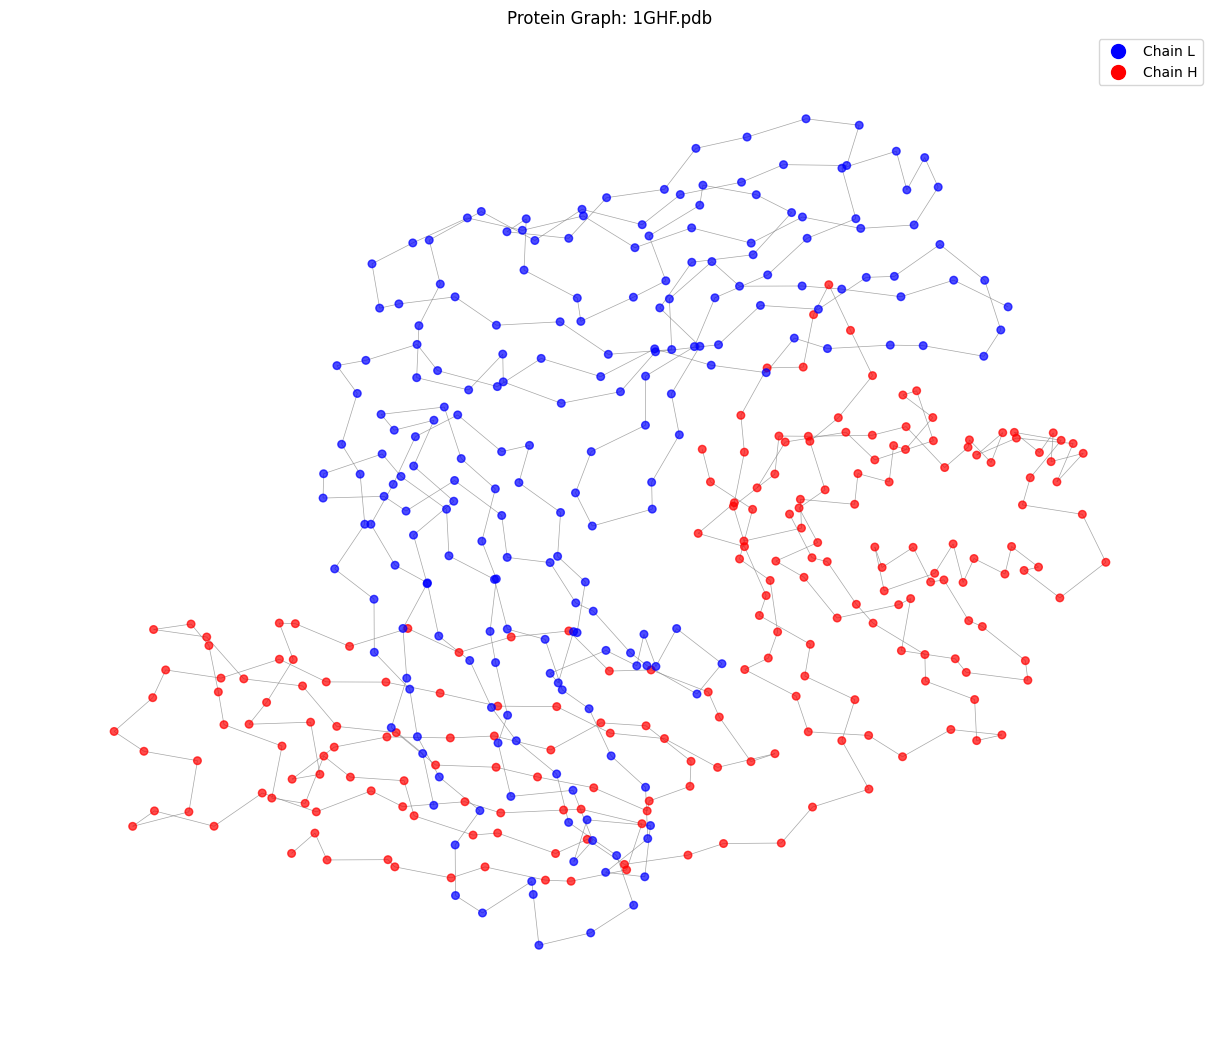

In [8]:
pdb_path = "fabs/1GHF.pdb"  # Use your path
result = test_process_single_pdb(pdb_path)

if result and result['nx_graph'].number_of_nodes() > 0:
    # Inspect the graph
    inspect_protein_graph(result['nx_graph'], os.path.basename(pdb_path))
    
    # Visualize the graph
    visualize_protein_graph(result['nx_graph'], os.path.basename(pdb_path))
else:
    print("Graph creation failed or graph is empty.")

## Use main function for the folder

In [9]:
# Process a folder of PDB files
processed_data = process_pdb_folder("fabs", "fabs_networkx")

Processing PDB files:   0%|          | 0/7 [00:00<?, ?it/s]

Output()

Processing PDB files:  14%|█▍        | 1/7 [00:03<00:23,  4.00s/it]

Saved graph to fabs_networkx/7AJ6_graph.pkl
Saved data to fabs_networkx/7AJ6_data.npy


Output()

...

Processing PDB files:  86%|████████▌ | 6/7 [00:36<00:06,  6.55s/it]

Output()

Saved data to fabs_networkx/1YUH_data.npy


Processing PDB files: 100%|██████████| 7/7 [00:40<00:00,  5.75s/it]

Saved graph to fabs_networkx/1GHF_graph.pkl
Saved data to fabs_networkx/1GHF_data.npy
Saved processing summary to fabs_networkx/processing_summary.json


#### Test of the folder with details and diagnostics

In [10]:
def process_folder_test(folder_path):
    """
    Test the processing pipeline on a folder of PDB files.
    
    Parameters:
    folder_path -- Path to folder containing PDB files
    
    Returns:
    Dictionary with processing results
    """
    import os
    from tqdm import tqdm
    
    # Get all PDB files in the folder
    pdb_files = [f for f in os.listdir(folder_path) if f.endswith('.pdb')]
    print(f"Found {len(pdb_files)} PDB files in {folder_path}")
    
    # Dictionary to store results
    results = {}
    
    # Process each file
    for pdb_file in tqdm(pdb_files, desc="Processing PDB files"):
        pdb_path = os.path.join(folder_path, pdb_file)
        pdb_id = os.path.splitext(pdb_file)[0]
        
        print(f"\nProcessing {pdb_file}...")
        try:
            # Parse PDB file
            atoms, residues_by_chain = parse_pdb(pdb_path)
            print(f"  Found {len(atoms)} atoms across {len(residues_by_chain)} chains")
            
            # Process data
            result = process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain)
            
            # Store basic info about the processing
            results[pdb_id] = {
                'success': True,
                'num_atoms': len(atoms),
                'num_chains': len(residues_by_chain),
                'num_nodes': result['nx_graph'].number_of_nodes(),
                'num_edges': result['nx_graph'].number_of_edges(),
                'chains': list(residues_by_chain.keys())
            }
            
            print(f"  Successfully created graph with {result['nx_graph'].number_of_nodes()} nodes and {result['nx_graph'].number_of_edges()} edges")
            
        except Exception as e:
            print(f"  Error processing {pdb_file}: {str(e)}")
            results[pdb_id] = {
                'success': False,
                'error': str(e)
            }
    
    # Summary
    successes = sum(1 for r in results.values() if r.get('success', False))
    print(f"\nProcessed {len(pdb_files)} PDB files with {successes} successes and {len(pdb_files) - successes} failures")
    
    return results

In [11]:
folder_path = "fabs"  # Update with your folder path
test_results = process_folder_test(folder_path)

# Print summary of results
print("\nSummary of processing results:")
for pdb_id, result in test_results.items():
    if result['success']:
        print(f"{pdb_id}: Success - {result['num_nodes']} nodes, {result['num_edges']} edges, {result['num_chains']} chains ({', '.join(result['chains'])})")
    else:
        print(f"{pdb_id}: Failed - {result.get('error', 'Unknown error')}")

Found 7 PDB files in fabs


Processing PDB files:   0%|          | 0/7 [00:00<?, ?it/s]


Processing 7AJ6.pdb...


Output()

  Found 3474 atoms across 2 chains


...

Processing PDB files:  86%|████████▌ | 6/7 [00:35<00:06,  6.31s/it]

Output()

  Successfully created graph with 858 nodes and 854 edges

Processing 1GHF.pdb...
  Found 3273 atoms across 2 chains


Processing PDB files: 100%|██████████| 7/7 [00:38<00:00,  5.51s/it]

  Successfully created graph with 423 nodes and 420 edges

Processed 7 PDB files with 7 successes and 0 failures

Summary of processing results:
7AJ6: Success - 431 nodes, 416 edges, 2 chains (L, H)
7UYL: Success - 559 nodes, 545 edges, 3 chains (H, L, K)
7JKB: Success - 449 nodes, 447 edges, 2 chains (A, B)
7U5G: Success - 439 nodes, 422 edges, 2 chains (H, L)
1SEQ: Success - 429 nodes, 413 edges, 2 chains (L, H)
1YUH: Success - 858 nodes, 854 edges, 4 chains (L, H, A, B)
1GHF: Success - 423 nodes, 420 edges, 2 chains (L, H)


## Addition of secondary structure, backbone info and calculations

**Bond Length Calculation:**  

    The bond length is computed by the Euclidean distance between two atoms using their positions in 3D space.

**Angle Calculation:**

    The angle is calculated between three atoms by computing the cosine of the angle between the vectors formed by these atoms using the dot product. The resulting value is then converted into degrees.

**Torsion Calculation:**

    The torsion angle is computed using four atoms. It involves calculating the cross products of the vectors formed by the atoms and applying the atan2 function to determine the dihedral angle.

In [58]:
def process_pdb_folder_complete(folder_path, output_path=None):
    """
    Process all PDB files in a folder with complete information including:
    - Secondary structure
    - Backbone atoms
    - Physical properties (bond lengths, angles, torsions)
    
    Parameters:
    folder_path -- Path to the folder containing PDB files
    output_path -- Optional path to save processed data
    
    Returns:
    Dictionary containing processed data for all PDB files
    """
    if output_path is None:
        output_path = os.path.join(folder_path, "processed_data")
    
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Get all PDB files in the folder
    pdb_files = [f for f in os.listdir(folder_path) if f.endswith('.pdb')]
    
    # Dictionary to store all processed data
    all_data = {}
    
    # Process each PDB file
    for pdb_file in tqdm(pdb_files, desc="Processing PDB files"):
        pdb_path = os.path.join(folder_path, pdb_file)
        pdb_id = os.path.splitext(pdb_file)[0]  # PDB ID without extension
        
        try:
            print(f"\nProcessing {pdb_file}...")
            
            # Parse PDB file
            atoms, residues_by_chain = parse_pdb(pdb_path)
            print(f"  Found {len(atoms)} atoms across {len(residues_by_chain)} chains")
            
            # Calculate secondary structure
            ss_data = calculate_secondary_structure(pdb_path)
            print(f"  Found secondary structure for {len(ss_data)} residues")
            
            # Create protein graph
            nx_graph = create_protein_graph(pdb_path)
            
            # Add secondary structure and backbone information
            nx_graph = add_structure_to_graph(nx_graph, ss_data)
            
            print(f"  Created graph with {nx_graph.number_of_nodes()} nodes and {nx_graph.number_of_edges()} edges")
            
            # Process data for this PDB
            pdb_data = {
                'pdb_id': pdb_id,
                'atoms': atoms,
                'residues_by_chain': residues_by_chain,
                'nx_graph': nx_graph,
                'relative_positions': {},
                'edge_indices': {},
                'bond_lengths': {},
                'angles': {},
                'torsions': {},
                'secondary_structure': {},
                'backbone_atoms': {},
                'charges': {},
                'hydrophobic_residues': {}
            }
            
            # Process each chain
            for chain_id, chain_residues in residues_by_chain.items():
                print(f"  Processing chain {chain_id}...")
                # Get atoms for this chain
                chain_atoms = [atom for atom in atoms if atom[0] == chain_id]
                
                # Extract positions
                positions = np.array([atom[5] for atom in chain_atoms])
                
                # Compute relative positions
                rel_pos = compute_relative_positions_chain(positions)
                
                # Create edge index for graph construction
                edge_index = create_edge_index(chain_atoms)
                
                # Get backbone atoms
                backbone_atoms = extract_backbone_atoms(chain_atoms)
                
                # Get secondary structure for this chain
                chain_ss = {res_id: ss_data.get((chain_id, res_id), '?') 
                           for res_id, _ in chain_residues}
                
                # Calculate physical properties
                bond_lengths = calculate_bond_lengths(chain_atoms, edge_index)
                angles = calculate_angles(chain_atoms, edge_index)
                torsions = calculate_torsions(chain_atoms, edge_index)
                charges = assign_charges(chain_atoms)
                hydrophobic = identify_hydrophobic_residues(chain_residues)
                
                # Store in PDB data dictionary
                pdb_data['relative_positions'][chain_id] = rel_pos
                pdb_data['edge_indices'][chain_id] = edge_index
                pdb_data['bond_lengths'][chain_id] = bond_lengths
                pdb_data['angles'][chain_id] = angles
                pdb_data['torsions'][chain_id] = torsions
                pdb_data['secondary_structure'][chain_id] = chain_ss
                pdb_data['backbone_atoms'][chain_id] = backbone_atoms
                pdb_data['charges'][chain_id] = charges
                pdb_data['hydrophobic_residues'][chain_id] = hydrophobic
            
            # Store in the main dictionary
            all_data[pdb_id] = pdb_data
            
            # Save processed data
            if output_path:
                # Save the NetworkX graph
                graph_path = os.path.join(output_path, f"{pdb_id}_graph.pkl")
                try:
                    import pickle
                    with open(graph_path, 'wb') as f:
                        pickle.dump(pdb_data['nx_graph'], f)
                    print(f"  Saved graph to {graph_path}")
                except Exception as e:
                    print(f"  Error saving graph for {pdb_id}: {str(e)}")
                
                # Save other data as numpy file
                data_to_save = {k: v for k, v in pdb_data.items() if k != 'nx_graph'}
                data_path = os.path.join(output_path, f"{pdb_id}_data.npy")
                try:
                    np.save(data_path, data_to_save)
                    print(f"  Saved data to {data_path}")
                except Exception as e:
                    print(f"  Error saving data for {pdb_id}: {str(e)}")
                
        except Exception as e:
            print(f"Error processing {pdb_file}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # Save summary
    summary = {}
    for pdb_id, pdb_data in all_data.items():
        summary[pdb_id] = {
            'num_atoms': len(pdb_data['atoms']),
            'num_chains': len(pdb_data['residues_by_chain']),
            'chains': list(pdb_data['residues_by_chain'].keys()),
            'num_nodes': pdb_data['nx_graph'].number_of_nodes(),
            'num_edges': pdb_data['nx_graph'].number_of_edges(),
            'has_secondary_structure': any(len(pdb_data['secondary_structure'].get(chain, {})) > 0 
                                          for chain in pdb_data['residues_by_chain']),
            'has_backbone_atoms': any(len(pdb_data['backbone_atoms'].get(chain, {})) > 0 
                                      for chain in pdb_data['residues_by_chain']),
            'physical_properties': {
                'bond_lengths': sum(len(pdb_data['bond_lengths'].get(chain, {})) 
                                   for chain in pdb_data['residues_by_chain']),
                'angles': sum(len(pdb_data['angles'].get(chain, {})) 
                             for chain in pdb_data['residues_by_chain']),
                'torsions': sum(len(pdb_data['torsions'].get(chain, {})) 
                               for chain in pdb_data['residues_by_chain'])
            }
        }
    
    summary_path = os.path.join(output_path, "processing_summary.json")
    try:
        import json
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"\nSaved processing summary to {summary_path}")
    except Exception as e:
        print(f"Error saving summary: {str(e)}")
    
    return all_data

def process_pdb_folder(folder_path, output_path=None):
    """
    Process all PDB files in a folder and prepare data for PINN GNN, including:
    - Secondary structure
    - Backbone atoms
    - Physical properties (bond lengths, angles, torsions)
    - Charges
    - Hydrophobic residues
    
    Parameters:
    folder_path -- Path to the folder containing PDB files
    output_path -- Optional path to save processed data
    
    Returns:
    Dictionary containing processed data for all PDB files
    """
    if output_path is None:
        output_path = os.path.join(folder_path, "processed_data")
    
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Get all PDB files in the folder
    pdb_files = [f for f in os.listdir(folder_path) if f.endswith('.pdb')]
    
    # Dictionary to store all processed data
    all_data = {}
    
    # Process each PDB file
    for pdb_file in tqdm(pdb_files, desc="Processing PDB files"):
        pdb_path = os.path.join(folder_path, pdb_file)
        pdb_id = os.path.splitext(pdb_file)[0]  # PDB ID without extension
        
        try:
            # Parse PDB file
            atoms, residues_by_chain = parse_pdb(pdb_path)
            
            # Calculate secondary structure
            ss_data = calculate_secondary_structure(pdb_path)
            
            # Create protein graph 
            nx_graph = create_protein_graph(pdb_path)
            
            # Add secondary structure and backbone information to the graph
            nx_graph = add_structure_to_graph(nx_graph, ss_data)
            
            # Create PDB data with graph
            pdb_data = {
                'pdb_id': pdb_id,
                'atoms': atoms,
                'residues_by_chain': residues_by_chain,
                'nx_graph': nx_graph,
                'relative_positions': {},
                'edge_indices': {},
                'bond_lengths': {},
                'angles': {},
                'torsions': {},
                'secondary_structure': {},
                'backbone_atoms': {},
                'charges': {},
                'hydrophobic_residues': {}
            }
            
            # Process each chain
            for chain_id, chain_residues in residues_by_chain.items():
                # Get atoms for this chain
                chain_atoms = [atom for atom in atoms if atom[0] == chain_id]
                
                # Extract positions
                positions = np.array([atom[5] for atom in chain_atoms])
                
                # Compute relative positions
                rel_pos = compute_relative_positions_chain(positions)
                
                # Create edge index for graph construction
                edge_index = create_edge_index(chain_atoms)
                
                # Get backbone atoms
                backbone_atoms = extract_backbone_atoms(chain_atoms)
                
                # Get secondary structure for this chain
                chain_ss = {res_id: ss_data.get((chain_id, res_id), '?') 
                           for res_id, _ in chain_residues}
                
                # Calculate physical properties
                bond_lengths = calculate_bond_lengths(chain_atoms, edge_index)
                angles = calculate_angles(chain_atoms, edge_index)
                torsions = calculate_torsions(chain_atoms, edge_index)
                charges = assign_charges(chain_atoms)
                hydrophobic = identify_hydrophobic_residues(chain_residues)
                
                # Store in PDB data dictionary
                pdb_data['relative_positions'][chain_id] = rel_pos
                pdb_data['edge_indices'][chain_id] = edge_index
                pdb_data['bond_lengths'][chain_id] = bond_lengths
                pdb_data['angles'][chain_id] = angles
                pdb_data['torsions'][chain_id] = torsions
                pdb_data['secondary_structure'][chain_id] = chain_ss
                pdb_data['backbone_atoms'][chain_id] = backbone_atoms
                pdb_data['charges'][chain_id] = charges
                pdb_data['hydrophobic_residues'][chain_id] = hydrophobic
            
            # Store in the main dictionary
            all_data[pdb_id] = pdb_data
            
            # Save processed data
            if output_path:
                # Save the NetworkX graph
                graph_path = os.path.join(output_path, f"{pdb_id}_graph.pkl")
                try:
                    import pickle
                    with open(graph_path, 'wb') as f:
                        pickle.dump(pdb_data['nx_graph'], f)
                    print(f"Saved graph to {graph_path}")
                except Exception as e:
                    print(f"Error saving graph for {pdb_id}: {str(e)}")
                
                # Save other data as numpy file
                data_to_save = {k: v for k, v in pdb_data.items() if k != 'nx_graph'}
                data_path = os.path.join(output_path, f"{pdb_id}_data.npy")
                try:
                    np.save(data_path, data_to_save)
                    print(f"Saved data to {data_path}")
                except Exception as e:
                    print(f"Error saving data for {pdb_id}: {str(e)}")
                
        except Exception as e:
            print(f"Error processing {pdb_file}: {str(e)}")
    
    # Save summary of all processed data
    summary = {}
    for pdb_id, pdb_data in all_data.items():
        summary[pdb_id] = {
            'num_atoms': len(pdb_data['atoms']),
            'num_chains': len(pdb_data['residues_by_chain']),
            'chains': list(pdb_data['residues_by_chain'].keys()),
            'num_nodes': pdb_data['nx_graph'].number_of_nodes(),
            'num_edges': pdb_data['nx_graph'].number_of_edges()
        }
    
    summary_path = os.path.join(output_path, "processing_summary.json")
    try:
        import json
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"Saved processing summary to {summary_path}")
    except Exception as e:
        print(f"Error saving summary: {str(e)}")
    
    return all_data

def process_single_pdb(pdb_id, pdb_path, atoms, residues_by_chain):
    """
    Process a single PDB file data for the PINN GNN model.
    
    Parameters:
    pdb_id -- Identifier for the PDB
    pdb_path -- Path to the PDB file
    atoms -- List of atom information from parse_pdb
    residues_by_chain -- Dictionary of residues by chain from parse_pdb
    
    Returns:
    Dictionary containing all processed data for this PDB
    """
    # Dictionary to store processed data
    pdb_data = {
        'pdb_id': pdb_id,
        'atoms': atoms,
        'residues_by_chain': residues_by_chain,
        'relative_positions': {},
        'edge_indices': {},
        'bond_lengths': {},
        'angles': {},
        'torsions': {},
        'secondary_structure': {},
        'backbone_atoms': {},
        'charges': {},
        'hydrophobic_residues': {},
        'nx_graph': None
    }
    
    # Calculate secondary structure using DSSP
    ss_data = calculate_secondary_structure(pdb_path)
    
    # Create NetworkX graph using Graphein
    nx_graph = create_protein_graph(pdb_path)
    pdb_data['nx_graph'] = nx_graph
    
    # Process each chain
    for chain_id, chain_residues in residues_by_chain.items():
        # Get atoms for this chain
        chain_atoms = [atom for atom in atoms if atom[0] == chain_id]
        
        # Extract positions
        positions = np.array([atom[5] for atom in chain_atoms])
        
        # Compute relative positions
        rel_pos = compute_relative_positions_chain(positions)
        
        # Create edge index for graph construction
        edge_index = create_edge_index(chain_atoms)
        
        # Get backbone atoms
        backbone_atoms = extract_backbone_atoms(chain_atoms)
        
        # Get secondary structure for this chain
        chain_ss = {res_id: ss_data.get((chain_id, res_id), '?') 
                   for res_id, _ in chain_residues}
        
        # Calculate physical properties
        bond_lengths = calculate_bond_lengths(chain_atoms, edge_index)
        angles = calculate_angles(chain_atoms, edge_index)
        torsions = calculate_torsions(chain_atoms, edge_index)
        charges = assign_charges(chain_atoms)
        hydrophobic = identify_hydrophobic_residues(chain_residues)
        
        # Store in PDB data dictionary
        pdb_data['relative_positions'][chain_id] = rel_pos
        pdb_data['edge_indices'][chain_id] = edge_index
        pdb_data['bond_lengths'][chain_id] = bond_lengths
        pdb_data['angles'][chain_id] = angles
        pdb_data['torsions'][chain_id] = torsions
        pdb_data['secondary_structure'][chain_id] = chain_ss
        pdb_data['backbone_atoms'][chain_id] = backbone_atoms
        pdb_data['charges'][chain_id] = charges
        pdb_data['hydrophobic_residues'][chain_id] = hydrophobic
    
    return pdb_data


def calculate_secondary_structure(pdb_path):
    """
    Calculate secondary structure using DSSP.
    
    Parameters:
    pdb_path -- Path to the PDB file
    
    Returns:
    Dictionary mapping (chain_id, residue_id) to secondary structure
    """
    try:
        parser = PDB.PDBParser(QUIET=True)
        structure = parser.get_structure("protein", pdb_path)
        model = structure[0]
        
        try:
            # Try direct DSSP call
            dssp = DSSP(model, pdb_path)
        except Exception as e1:
            try:
                # Fallback: Try with DSSP executable if installed
                from Bio.PDB.DSSP import dssp_dict_from_pdb_file
                dssp_dict, dssp_keys = dssp_dict_from_pdb_file(pdb_path)
                
                # Convert to format similar to DSSP object
                dssp = {}
                for key in dssp_keys:
                    dssp[key] = dssp_dict[key]
            except Exception as e2:
                print(f"DSSP calculation failed: {str(e1)} | {str(e2)}")
                # If all methods fail, use a simple fallback
                return {}
        
        ss_data = {}
        
        for key in dssp.keys():
            if isinstance(key, tuple):
                # Newer DSSP version
                chain_id = key[0]
                res_id = key[1][1]  # Residue number
                if isinstance(dssp[key], dict):
                    ss = dssp[key].get('secstruct', '?')
                else:
                    # Older DSSP version
                    ss = dssp[key][2]  # Secondary structure
            else:
                # Alternative key format
                chain_id, res_id = key[0], key[1]
                ss = dssp[key][2]
                
            ss_data[(chain_id, res_id)] = ss
        
        return ss_data
    except Exception as e:
        print(f"Secondary structure calculation failed: {str(e)}")
        return {}

def create_protein_graph(pdb_path, ss_data=None):
    """
    Create a protein graph using Graphein or fallback to custom implementation.
    
    Parameters:
    pdb_path -- Path to the PDB file
    ss_data -- Optional secondary structure data dictionary
    
    Returns:
    NetworkX graph
    """
    try:
        # Try the current Graphein API
        import graphein.protein as gp
        
        # Check the actual function signature
        import inspect
        sig = inspect.signature(gp.construct_graph)
        
        # Check if 'pdb_path' is a parameter
        if 'pdb_path' in sig.parameters:
            graph = gp.construct_graph(pdb_path=pdb_path)
        elif 'path' in sig.parameters:
            # Try with 'path' instead
            graph = gp.construct_graph(path=pdb_path)
        else:
            # Check if the function expects the first argument to be the path
            params = list(sig.parameters.keys())
            if len(params) > 0:
                # Try with positional argument
                graph = gp.construct_graph(pdb_path)
            else:
                raise ValueError("Cannot determine correct parameters for construct_graph")
                
        return graph
        
    except Exception as e:
        print(f"Graphein error: {str(e)}")
        print("Falling back to custom graph implementation...")
        
        # Create a simple graph using NetworkX and BioPython
        parser = PDB.PDBParser(QUIET=True)
        structure = parser.get_structure("protein", pdb_path)
        
        # Create basic graph
        graph = nx.Graph()
        
        # Add nodes for each residue
        for model in structure:
            for chain in model:
                chain_id = chain.get_id()
                for residue in chain:
                    # Skip non-standard residues
                    if residue.get_id()[0] != " ":
                        continue
                        
                    res_id = residue.get_id()[1]
                    res_name = residue.get_resname()
                    
                    # Add node
                    node_id = f"{chain_id}:{res_name}:{res_id}"
                    graph.add_node(
                        node_id,
                        chain_id=chain_id,
                        residue_number=res_id,
                        residue_name=res_name
                    )
                    
                    # Add atom data and track if backbone atoms are present
                    has_backbone = False
                    for atom in residue:
                        atom_name = atom.get_name()
                        coord = atom.get_coord()
                        
                        # Store coordinates of backbone atoms
                        if atom_name in ['CA', 'N', 'C', 'O']:
                            graph.nodes[node_id][atom_name] = coord
                            has_backbone = True
                    
                    # Set backbone flag
                    graph.nodes[node_id]['has_backbone'] = has_backbone
                    
                    # Store CA coordinates for distance calculations
                    if 'CA' in graph.nodes[node_id]:
                        graph.nodes[node_id]['coords'] = graph.nodes[node_id]['CA']
                    
                    # Add secondary structure if available
                    if ss_data and (chain_id, res_id) in ss_data:
                        graph.nodes[node_id]['ss'] = ss_data[(chain_id, res_id)]
                    else:
                        graph.nodes[node_id]['ss'] = '?'
        
        # Add edges between consecutive residues and close residues
        # First, sort nodes by chain and residue number
        sorted_nodes = sorted(graph.nodes(), key=lambda x: (x.split(':')[0], int(x.split(':')[2]) if x.split(':')[2].isdigit() else 0))
        
        # Add backbone connections
        for i in range(len(sorted_nodes) - 1):
            node1 = sorted_nodes[i]
            chain1, _, res1 = node1.split(':')
            
            for j in range(i + 1, min(i + 20, len(sorted_nodes))):  # Check only nearby residues
                node2 = sorted_nodes[j]
                chain2, _, res2 = node2.split(':')
                
                # Add edge if same chain and sequential
                if chain1 == chain2 and abs(int(res1) - int(res2)) == 1:
                    graph.add_edge(node1, node2, kind={'peptide_bond'})
                
                # Add edge if CA atoms are within 7 Angstroms
                if 'coords' in graph.nodes[node1] and 'coords' in graph.nodes[node2]:
                    ca1 = graph.nodes[node1]['coords']
                    ca2 = graph.nodes[node2]['coords']
                    distance = np.linalg.norm(ca1 - ca2)
                    
                    if distance < 7.0:  # 7 Angstrom cutoff
                        graph.add_edge(node1, node2, kind={'contact'}, distance=distance)
        
        return graph

def extract_backbone_atoms(chain_atoms):
    """
    Extract backbone atoms (N, CA, C, O) from a chain.
    
    Parameters:
    chain_atoms -- List of atoms in a chain
    
    Returns:
    Dictionary mapping residue IDs to backbone atom positions
    """
    backbone = {}
    
    for atom in chain_atoms:
        chain_id, res_id, res_name, atom_name, element, position = atom
        
        if atom_name in ['N', 'CA', 'C', 'O']:
            if res_id not in backbone:
                backbone[res_id] = {}
            backbone[res_id][atom_name] = position
    
    return backbone

def compute_relative_positions_chain(positions):
    """Compute relative positions between atoms in a chain."""
    n_atoms = positions.shape[0]
    rel_pos = np.zeros((n_atoms, n_atoms, 3))
    
    for i in range(n_atoms):
        for j in range(n_atoms):
            rel_pos[i, j] = positions[j] - positions[i]
    
    return rel_pos

def create_edge_index(chain_atoms):
    """Create edge index for graph construction."""
    n_atoms = len(chain_atoms)
    edges = []
    
    # Example: Connect atoms within the same residue and consecutive residues
    for i in range(n_atoms):
        res_i = chain_atoms[i][1]  # Residue ID
        for j in range(i+1, n_atoms):
            res_j = chain_atoms[j][1]  # Residue ID
            if res_i == res_j or abs(res_i - res_j) == 1:
                edges.append([i, j])
                edges.append([j, i])  # For undirected graph
    
    return np.array(edges).T if edges else np.zeros((2, 0), dtype=int)

def calculate_bond_lengths(chain_atoms, edge_index):
    """Calculate bond lengths between atoms."""
    bond_lengths = {}
    for i, j in zip(*edge_index):
        atom_i = chain_atoms[i]
        atom_j = chain_atoms[j]
        position_i = np.array(atom_i[5])  # Atomic coordinates (x, y, z) for atom i
        position_j = np.array(atom_j[5])  # Atomic coordinates (x, y, z) for atom j
        
        # Calculate Euclidean distance
        bond_length = np.linalg.norm(position_i - position_j)
        bond_lengths[(i, j)] = bond_length
    
    return bond_lengths

def calculate_angles(chain_atoms, edge_index):
    """Calculate angles between atoms."""
    angles = {}
    for i, j, k in zip(*edge_index):
        atom_i = chain_atoms[i]
        atom_j = chain_atoms[j]
        atom_k = chain_atoms[k]
        
        pos_i = np.array(atom_i[5])  # Atomic coordinates (x, y, z) for atom i
        pos_j = np.array(atom_j[5])  # Atomic coordinates (x, y, z) for atom j
        pos_k = np.array(atom_k[5])  # Atomic coordinates (x, y, z) for atom k
        
        # Create vectors
        vec_ij = pos_i - pos_j
        vec_jk = pos_k - pos_j
        
        # Compute angle using the cosine of the angle
        cos_angle = np.dot(vec_ij, vec_jk) / (np.linalg.norm(vec_ij) * np.linalg.norm(vec_jk))
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # Clipping for numerical stability
        
        angles[(i, j, k)] = np.degrees(angle)  # Convert to degrees
    
    return angles

def calculate_torsions(chain_atoms, edge_index):
    """Calculate torsion (dihedral) angles between atoms."""
    torsions = {}
    for i, j, k, l in zip(*edge_index):
        atom_i = chain_atoms[i]
        atom_j = chain_atoms[j]
        atom_k = chain_atoms[k]
        atom_l = chain_atoms[l]
        
        pos_i = np.array(atom_i[5])
        pos_j = np.array(atom_j[5])
        pos_k = np.array(atom_k[5])
        pos_l = np.array(atom_l[5])
        
        # Define vectors
        v1 = pos_j - pos_i
        v2 = pos_k - pos_j
        v3 = pos_l - pos_k
        
        # Cross products
        n1 = np.cross(v1, v2)
        n2 = np.cross(v2, v3)
        
        # Normalize
        n1 = n1 / np.linalg.norm(n1)
        n2 = n2 / np.linalg.norm(n2)
        
        # Compute torsion angle
        torsion = np.arctan2(np.dot(np.cross(n1, n2), v2) / np.linalg.norm(v2), np.dot(n1, n2))
        
        torsions[(i, j, k, l)] = np.degrees(torsion)  # Convert to degrees
    
    return torsions

def assign_charges(chain_atoms):
    """
    Assign partial charges to atoms based on residue type and atom name.
    
    This is a simplified version - you may want to use a more accurate charge model.
    """
    charges = {}
    
    # Simplified charge assignment based on atom types
    charge_map = {
        'N': -0.5,   # Backbone nitrogen
        'C': 0.5,    # Backbone carbon
        'O': -0.5,   # Carbonyl oxygen
        'S': 0.0,    # Sulfur
        'P': 0.5     # Phosphorus
    }
    
    for i, atom in enumerate(chain_atoms):
        chain_id, res_id, res_name, atom_name, element, position = atom
        charges[i] = charge_map.get(element, 0.0)
    
    return charges

def identify_hydrophobic_residues(chain_residues):
    """
    Identify hydrophobic residues in a chain.
    
    Parameters:
    chain_residues -- List of residues in a chain
    
    Returns:
    Set of residue IDs that are hydrophobic
    """
    hydrophobic_aas = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'TYR'}
    hydrophobic_res_ids = set()
    
    for res_id, res_name in chain_residues:
        if res_name in hydrophobic_aas:
            hydrophobic_res_ids.add(res_id)
    
    return hydrophobic_res_ids


def add_structure_to_graph(graph, ss_data):
    """
    Add secondary structure and backbone information to a protein graph.
    
    Parameters:
    graph -- NetworkX graph to update
    ss_data -- Dictionary of secondary structure data
    
    Returns:
    Updated NetworkX graph
    """
    for node, data in graph.nodes(data=True):
        # Extract chain and residue information
        if ':' in node:  # Format like 'H:VAL:1'
            parts = node.split(':')
            chain_id = parts[0]
            if len(parts) >= 3:
                try:
                    residue_id = int(parts[2])
                except ValueError:
                    residue_id = parts[2]
        else:
            # Try to extract from attributes
            chain_id = data.get('chain_id', '')
            residue_id = data.get('residue_number', None)
        
        # Add secondary structure if available
        if (chain_id, residue_id) in ss_data:
            graph.nodes[node]['ss'] = ss_data[(chain_id, residue_id)]
        else:
            graph.nodes[node]['ss'] = '?'
        
        # Check for backbone atoms using exact attribute names from Graphein
        backbone_keys = ['CA', 'C', 'N', 'O', 'atom_type', 'element_symbol', 'coords']
        backbone_atoms_present = False
        
        for key in data.keys():
            # Check for backbone atom coordinates or any CA atom indicator
            if key in ['CA', 'C', 'N', 'O']:
                backbone_atoms_present = True
                break
            elif key == 'atom_type' and data[key] in ['CA', 'C', 'N', 'O']:
                backbone_atoms_present = True
                break
        
        # For debugging, print the first node's data
        if node == list(graph.nodes())[0]:
            print(f"First node data keys: {list(data.keys())}")
            print(f"Checking for backbone atoms: {backbone_atoms_present}")
            
        # Add backbone information
        graph.nodes[node]['has_backbone'] = backbone_atoms_present
    
    return graph

def add_backbone_from_pdb(graph, pdb_path):
    """
    Add backbone information to the graph by directly extracting it from the PDB file.
    
    Parameters:
    graph -- NetworkX graph to update
    pdb_path -- Path to the PDB file
    
    Returns:
    Updated NetworkX graph
    """
    # Parse PDB file
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_path)
    
    # Extract backbone atoms
    backbone_info = {}
    for model in structure:
        for chain in model:
            chain_id = chain.get_id()
            for residue in chain:
                if residue.get_id()[0] != " ":  # Skip non-standard residues
                    continue
                    
                res_id = residue.get_id()[1]
                
                # Check for backbone atoms
                backbone_atoms = {}
                for atom_name in ['CA', 'N', 'C', 'O']:
                    if atom_name in residue:
                        backbone_atoms[atom_name] = residue[atom_name].get_coord()
                
                if backbone_atoms:
                    backbone_info[(chain_id, res_id)] = backbone_atoms
    
    # Add backbone info to graph
    for node, data in graph.nodes(data=True):
        # Extract chain and residue ID
        if ':' in node:
            parts = node.split(':')
            chain_id = parts[0]
            if len(parts) >= 3:
                try:
                    res_id = int(parts[2])
                except ValueError:
                    res_id = parts[2]
                    
                # Check if we have backbone info for this residue
                if (chain_id, res_id) in backbone_info:
                    # Add backbone atom coordinates
                    for atom_name, coord in backbone_info[(chain_id, res_id)].items():
                        graph.nodes[node][atom_name] = coord
                    
                    # Set backbone flag
                    graph.nodes[node]['has_backbone'] = True
                else:
                    graph.nodes[node]['has_backbone'] = False
        else:
            # Extract from attributes if possible
            chain_id = data.get('chain_id', '')
            res_id = data.get('residue_number', None)
            
            if chain_id and res_id and (chain_id, res_id) in backbone_info:
                # Add backbone atom coordinates
                for atom_name, coord in backbone_info[(chain_id, res_id)].items():
                    graph.nodes[node][atom_name] = coord
                
                # Set backbone flag
                graph.nodes[node]['has_backbone'] = True
    
    return graph

### Test on a single pdb

In [52]:
def inspect_protein_graph(graph, pdb_id=None):
    """
    Inspect a protein graph to verify its structure and properties.
    
    Parameters:
    graph -- NetworkX graph object to inspect
    pdb_id -- Optional PDB ID for display purposes
    
    Returns:
    None (prints information to console)
    """
    if pdb_id:
        print(f"\n==== INSPECTING PROTEIN GRAPH: {pdb_id} ====\n")
    else:
        print("\n==== INSPECTING PROTEIN GRAPH ====\n")
    
    # Basic graph information
    print(f"Graph type: {type(graph)}")
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    
    # Check node information
    if graph.number_of_nodes() > 0:
        print("\n-- NODE INFORMATION --")
        # Get a sample node
        sample_node = next(iter(graph.nodes()))
        print(f"\nSample node ID: {sample_node}")
        print("Node attributes:")
        for key, value in graph.nodes[sample_node].items():
            if isinstance(value, np.ndarray) and value.size > 10:
                print(f"  {key}: <ndarray shape={value.shape}, dtype={value.dtype}>")
            else:
                print(f"  {key}: {value}")
        
        # Count of nodes by chain
        chains = {}
        for node in graph.nodes():
            chain = graph.nodes[node].get('chain_id', 'Unknown')
            chains[chain] = chains.get(chain, 0) + 1
        print("\nNodes by chain:")
        for chain, count in chains.items():
            print(f"  Chain {chain}: {count} nodes")
    
    # Check edge information
    if graph.number_of_edges() > 0:
        print("\n-- EDGE INFORMATION --")
        # Get a sample edge
        sample_edge = next(iter(graph.edges()))
        print(f"\nSample edge: {sample_edge}")
        print("Edge attributes:")
        for key, value in graph.edges[sample_edge].items():
            print(f"  {key}: {value}")
        
        # Count edge types
        edge_types = {}
        for u, v, data in graph.edges(data=True):
            # Handle different possible formats of 'kind' attribute
            kind = data.get('kind', 'Unknown')
            
            if isinstance(kind, set):
                # If kind is a set, convert to tuple for hashing
                for k in kind:
                    edge_types[k] = edge_types.get(k, 0) + 1
            elif isinstance(kind, list):
                # If kind is a list, count each type
                for k in kind:
                    edge_types[k] = edge_types.get(k, 0) + 1
            else:
                # Otherwise use as-is
                edge_types[kind] = edge_types.get(kind, 0) + 1
        
        print("\nEdge types:")
        for edge_type, count in edge_types.items():
            print(f"  {edge_type}: {count} edges")
    
    # Check for secondary structure
    ss_present = 0
    ss_types = {}
    for node, data in graph.nodes(data=True):
        if 'ss' in data and data['ss'] != '?':
            ss_present += 1
            ss_types[data['ss']] = ss_types.get(data['ss'], 0) + 1
    
    if ss_present > 0:
        print(f"\nSecondary structure information: Present in {ss_present} nodes")
        print("Secondary structure types:")
        for ss_type, count in ss_types.items():
            ss_names = {
                'H': 'Alpha Helix',
                'B': 'Beta Bridge',
                'E': 'Extended Strand',
                'G': '3-10 Helix',
                'I': 'Pi Helix',
                'T': 'Turn',
                'S': 'Bend',
                ' ': 'Coil',
                '-': 'None'
            }
            name = ss_names.get(ss_type, ss_type)
            print(f"  {ss_type} ({name}): {count} nodes")
    else:
        print(f"\nSecondary structure information: Missing")
    
    # Check for backbone atoms
    backbone_present = 0
    for node, data in graph.nodes(data=True):
        if data.get('has_backbone', False):
            backbone_present += 1
    
    if backbone_present > 0:
        print(f"Backbone atom information: Present in {backbone_present} nodes")
    else:
        print(f"Backbone atom information: Missing")
    
    print("\n==== INSPECTION COMPLETE ====\n")

In [26]:
def test_structure_info(pdb_path):
    """
    Test secondary structure and backbone information.
    
    Parameters:
    pdb_path -- Path to PDB file
    
    Returns:
    NetworkX graph with structure information
    """
    print(f"Testing secondary structure and backbone info for: {pdb_path}")
    pdb_id = os.path.splitext(os.path.basename(pdb_path))[0]
    
    # Parse PDB
    atoms, residues_by_chain = parse_pdb(pdb_path)
    print(f"Found {len(atoms)} atoms across {len(residues_by_chain)} chains")
    
    # Calculate secondary structure
    ss_data = calculate_secondary_structure(pdb_path)
    print(f"Found secondary structure for {len(ss_data)} residues")
    
    # Create graph
    nx_graph = create_protein_graph(pdb_path)
    print(f"Created graph with {nx_graph.number_of_nodes()} nodes and {nx_graph.number_of_edges()} edges")
    
    # Add structure info
    nx_graph = add_structure_to_graph(nx_graph, ss_data)
    
    # If backbone info is still missing, try direct extraction from PDB
    backbone_present = 0
    for node, data in nx_graph.nodes(data=True):
        if data.get('has_backbone', False):
            backbone_present += 1
    
    print(f"Nodes with backbone info after first method: {backbone_present}")
    
    if backbone_present == 0:
        print("Using PDB file to extract backbone information...")
        nx_graph = add_backbone_from_pdb(nx_graph, pdb_path)
        
        backbone_present = 0
        for node, data in nx_graph.nodes(data=True):
            if data.get('has_backbone', False):
                backbone_present += 1
        
        print(f"Nodes with backbone info after PDB extraction: {backbone_present}")
    
    # Count SS info
    ss_present = 0
    for node, data in nx_graph.nodes(data=True):
        if 'ss' in data and data['ss'] != '?':
            ss_present += 1
    
    print(f"Nodes with SS info: {ss_present}")
    
    # Inspect graph
    inspect_protein_graph(nx_graph, pdb_id)
    
    return nx_graph



In [53]:
# Test on your PDB file
pdb_path = "fabs/1GHF.pdb"  # Update with your path
result_graph = test_structure_info(pdb_path)

Output()

Testing secondary structure and backbone info for: fabs/1GHF.pdb
Found 3273 atoms across 2 chains
Found secondary structure for 423 residues


Created graph with 423 nodes and 420 edges
First node data keys: ['chain_id', 'residue_name', 'residue_number', 'atom_type', 'element_symbol', 'coords', 'b_factor', 'meiler', 'ss']
Checking for backbone atoms: True
Nodes with backbone info after first method: 423
Nodes with SS info: 423

==== INSPECTING PROTEIN GRAPH: 1GHF ====

Graph type: <class 'networkx.classes.graph.Graph'>
Number of nodes: 423
Number of edges: 420

-- NODE INFORMATION --

Sample node ID: H:VAL:1
Node attributes:
  chain_id: H
  residue_name: VAL
  residue_number: 1
  atom_type: CA
  element_symbol: C
  coords: [78.176 45.718 -9.696]
  b_factor: 11.399999618530273
  meiler: dim_1    3.67
dim_2    0.14
dim_3    3.00
dim_4    1.22
dim_5    6.02
dim_6    0.27
dim_7    0.49
Name: VAL, dtype: float64
  ss: -
  has_backbone: True

Nodes by chain:
  Chain H: 212 nodes
  Chain L: 211 nodes

-- EDGE INFORMATION --

Sample edge: ('H:VAL:1', 'H:GLN:2')
Edge attributes:
  kind: {'peptide_bond'}
  distance: 3.811268662509169



In [59]:
folder_path = "fabs"  # Update with your path
process_pdb_folder_complete(folder_path, 'fabs_networkx')

Processing PDB files:   0%|          | 0/7 [00:00<?, ?it/s]

Output()


Processing 7AJ6.pdb...
  Found 3474 atoms across 2 chains
  Found secondary structure for 418 residues


First node data keys: ['chain_id', 'residue_name', 'residue_number', 'atom_type', 'element_symbol', 'coords', 'b_factor', 'meiler', 'ss']
Checking for backbone atoms: True
  Created graph with 431 nodes and 416 edges
  Processing chain L...


Traceback (most recent call last):
  File "/tmp/ipykernel_34142/1954803171.py", line 92, in process_pdb_folder_complete
    angles = calculate_angles(chain_atoms, edge_index)
  File "/tmp/ipykernel_34142/1954803171.py", line 645, in calculate_angles
    for i, j, k in zip(*edge_index):
ValueError: not enough values to unpack (expected 3, got 2)
Processing PDB files:  14%|█▍        | 1/7 [00:01<00:11,  1.88s/it]

...

Error processing 1YUH.pdb: not enough values to unpack (expected 3, got 2)

Processing 1GHF.pdb...
  Found 3273 atoms across 2 chains
  Found secondary structure for 423 residues


First node data keys: ['chain_id', 'residue_name', 'residue_number', 'atom_type', 'element_symbol', 'coords', 'b_factor', 'meiler', 'ss']
Checking for backbone atoms: True
  Created graph with 423 nodes and 420 edges
  Processing chain L...


Traceback (most recent call last):
  File "/tmp/ipykernel_34142/1954803171.py", line 92, in process_pdb_folder_complete
    angles = calculate_angles(chain_atoms, edge_index)
  File "/tmp/ipykernel_34142/1954803171.py", line 645, in calculate_angles
    for i, j, k in zip(*edge_index):
ValueError: not enough values to unpack (expected 3, got 2)
Processing PDB files: 100%|██████████| 7/7 [00:19<00:00,  2.77s/it]

Error processing 1GHF.pdb: not enough values to unpack (expected 3, got 2)

Saved processing summary to fabs_networkx/processing_summary.json


{}

# Partial summary

**Node Information**: nodes currently have the following main attributes:

chain_id: The chain identifier (e.g., 'H', 'L')  
residue_name: The 3-letter amino acid code (e.g., 'VAL', 'GLY')  
residue_number: The residue sequence number  
atom_type: The atom type (e.g., 'CA' for alpha carbon)  
element_symbol: The chemical element (e.g., 'C', 'N', 'O')  
coords: The 3D coordinates of the atom  
b_factor: Temperature factor (indicates flexibility)  
meiler: Meiler encoding (physicochemical properties)  
ss: Secondary structure assignment (e.g., 'H' for helix)  
has_backbone: Boolean indicating if backbone atoms are present   

**Edge Information**: edges represent connections between residues and have:

kind: The type of connection (e.g., 'peptide_bond' for sequential residues)  
distance: The distance between the connected residues (in Angstroms)  

# Still to do: 

- Add angles
- Add torsions (dihedral angles)
- add partial charges
- Anything additional i'd need for the loss?
- anything additional I need for the optimization problem?
- Is the graph multilayer?

# test global preprocess